# ResNET

## Description
1. Project is based on this article [ResNet](https://arxiv.org/pdf/1512.03385)
2. I will be implementing ResNet 34 and 56
3. Trained on CIFAR100

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torchsummary import summary

from torch.utils.data import random_split, DataLoader, Subset

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import numpy as np

import tqdm

import pickle

import os,json

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading data

In [ ]:
# TRANSFORMACJE
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std=[0.2675, 0.2565, 0.2761]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std=[0.2675, 0.2565, 0.2761]
    )
])

# DATASETY
raw_train_data = datasets.CIFAR100(root='data', train=True, download=True)

num_train = len(raw_train_data)
indices = list(range(num_train))
split = int(np.floor(0.1 * num_train))

np.random.seed(42)
np.random.shuffle(indices)

print(indices[:40:2])

train_idx, val_idx = indices[split:], indices[:split]


train_dataset_full = datasets.CIFAR100(root='data', train=True, download=False, transform=train_transform)
val_dataset_full = datasets.CIFAR100(root='data', train=True, download=False, transform=test_transform)

mnist_train = Subset(train_dataset_full, train_idx)
mnist_val = Subset(val_dataset_full, val_idx)
mnist_test = datasets.CIFAR100(root='data', train=False, download=True, transform=test_transform);

# LOADERY
train_loader = DataLoader(dataset=mnist_train, batch_size=128, shuffle=True, pin_memory=True)
val_loader = DataLoader(dataset=mnist_val, batch_size=1000, shuffle=False, pin_memory=True)
test_loader = DataLoader(dataset=mnist_test, batch_size=1000, shuffle=False, pin_memory=True)

print(f"Trening: {len(mnist_train)}, Walidacja: {len(mnist_val)}, Test: {len(mnist_test)}")

100%|██████████| 169M/169M [05:13<00:00, 538kB/s]


[33553, 199, 39489, 10822, 4144, 43106, 6188, 18471, 15177, 12609, 6113, 821, 13466, 42111, 37237, 36480, 5503, 38478, 49717, 47609]
Trening: 45000, Walidacja: 5000, Test: 10000


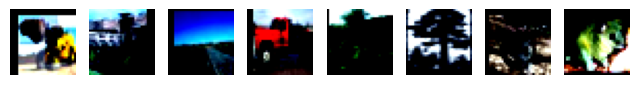

In [ ]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 8, 1
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(mnist_train), size=(1,)).item()
    img, label = mnist_train[sample_idx]
    img = img.numpy()
    img = img.transpose((1,2,0))
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img, cmap="gray")
plt.show()

## Model Architecture

In [ ]:
class ResNetBlock(nn.Module):
  expansion = 1

  def __init__(self, in_channels, out_channels, indentity_downsample=None,stride=1):
    super().__init__()


    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU()

    self.indentity_downsample = indentity_downsample

  def forward(self, x):
    identity = x

    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.bn2(x)

    if self.indentity_downsample is not None:
      identity = self.indentity_downsample(identity)

    x += identity
    x = self.relu(x)
    return x


In [ ]:
class ResNetBottleNeckBlock(nn.Module):
  expansion = 4

  def __init__(self, in_channels, out_channels, indentity_downsample=None,stride=1):
    super().__init__()


    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1)
    self.bn1 = nn.BatchNorm2d(out_channels)

    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.conv3 = nn.Conv2d(out_channels, out_channels*self.expansion, kernel_size=1, stride=1)
    self.bn3 = nn.BatchNorm2d(out_channels*self.expansion)

    self.relu = nn.ReLU()
    self.indentity_downsample = indentity_downsample

  def forward(self, x):
    identity = x

    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.bn3(x)

    if self.indentity_downsample is not None:
      identity = self.indentity_downsample(identity)

    x += identity
    x = self.relu(x)
    return x


In [ ]:
class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super().__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)

In [ ]:
class ResNet(nn.Module):
  def __init__(self, block, image_channels, num_classes, block_layers_size, block_channels_size, stem_maxpool=True, stem_kernel_size=7, stem_stride=2,stem_padding=3, shortcut_type='B'):
    super().__init__()

    if(len(block_channels_size) != len(block_layers_size)):
      raise ValueError("block_channels_size and block_layers_num must have the same length")
    elif(len(block_layers_size) <= 0):
      raise ValueError("You have to have at least one layer of blocks")

    self.in_channels = block_channels_size[0]
    self.expansion = block.expansion
    self.shortcut_type = shortcut_type

    # ====== LAYERS ======
    # stem layers
    self.conv1 = nn.Conv2d(image_channels, block_channels_size[0], kernel_size=stem_kernel_size, stride=stem_stride, padding=stem_padding, bias=False)
    self.bn1 = nn.BatchNorm2d(block_channels_size[0])
    self.relu = nn.ReLU()
    self.maxpool = None
    if stem_maxpool:
      self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    # ResNet Blocks
    self.layers = nn.ModuleList()

    for i,(number_of_blocks, out_channel_size) in enumerate(zip(block_layers_size, block_channels_size)):
      # no stride on the first layer
      if i == 0:
        self.layers.append(self._make_layer(block_class=block, n_blocks=number_of_blocks, stride=1, out_channels=out_channel_size))
      else:
        self.layers.append(self._make_layer(block_class=block, n_blocks=number_of_blocks, stride=2, out_channels=out_channel_size))


    # Final avgpool and FF layer
    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(self.in_channels, num_classes)




  def _make_layer(self, block_class, n_blocks, stride, out_channels):
    indentity_downsample = None
    layers = []

    if stride != 1 or self.in_channels != out_channels*self.expansion:
      # indentity_downsample = nn.Sequential(
      #     nn.Conv2d(self.in_channels, out_channels*self.expansion, kernel_size=1, stride=stride),
      #     nn.BatchNorm2d(out_channels*self.expansion)
      # )
      if self.shortcut_type == 'B':
          # klasyczny conv 1x1 + BN
        indentity_downsample = nn.Sequential(
            nn.Conv2d(self.in_channels, out_channels * self.expansion, kernel_size=1, stride=stride),
            nn.BatchNorm2d(out_channels * self.expansion)
        )
      elif self.shortcut_type == 'A':
            # Obliczamy ile zer dokleić
            pad_channels = out_channels * self.expansion - self.in_channels

            # Definiujemy funkcję paddingu
            def pad_func(x):
                # 1. Przestrzenny downsampling (co drugi piksel)
                # ::stride - bierze co n-ty element
                x = x[:, :, ::stride, ::stride]

                # 2. Padding kanałów
                # Tworzymy tensor zer o takich samych wymiarach H, W, N, ale 'pad_channels' kanałów
                zeros = torch.zeros(x.shape[0], pad_channels, x.shape[2], x.shape[3], device=x.device)

                # Doklejamy zera do kanałów
                return torch.cat((x, zeros), dim=1)

            indentity_downsample = LambdaLayer(pad_func)
      else:
        raise ValueError("Invalid shortcut type")

    layers.append(block_class(self.in_channels, out_channels, indentity_downsample, stride=stride))

    self.in_channels = out_channels*self.expansion

    for i in range(n_blocks - 1):
      layers.append(block_class(self.in_channels, out_channels))

    return nn.Sequential(*layers)





  def forward(self, x):
    # stem flow
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    if self.maxpool is not None:
      x = self.maxpool(x)

    # resnet blocks flow
    for layer in self.layers:
      x = layer(x)

    # final layer avg flow, and logits return
    x = self.avgpool(x)
    x = x.reshape(x.shape[0], -1)
    x = self.fc(x)

    return x




In [ ]:
# ====== ResNet-34 ====== standard blocks
resnet34 = ResNet(
    block=ResNetBlock,
    image_channels=3,
    num_classes=100,              # CIFAR-100
    block_layers_size=[3, 4, 6, 3],
    block_channels_size=[64, 128, 256, 512],
    stem_maxpool=False,
    stem_kernel_size=3,
    stem_stride=1,
    stem_padding=1,
    shortcut_type='B'
)

# ====== ResNet-56 ====== bottleneck blocks, CIFAR-style
resnet56 = ResNet(
    block=ResNetBlock,
    image_channels=3,
    num_classes=100,
    block_layers_size=[9, 9, 9],  # 6n+2 = 56 -> n=9
    block_channels_size=[16, 32, 64],
    stem_maxpool=False,           # CIFAR paper nie używa maxpool na początku
    stem_kernel_size=3,
    stem_stride=1,
    stem_padding=1,
    shortcut_type='A'
)

In [ ]:
if (not torch.cuda.is_available()):
  summary(resnet34, (3, 32, 32))

In [ ]:
if (not torch.cpu.is_available()):
  summary(resnet56, (3, 32, 32))

## Train, validation and test funcs

In [ ]:
def train_epoch(model, train_loader, optimizer, criterion, device, num_of_epoch=0):
    model.train()
    epoch_loss = 0.0
    epoch_acc = 0.0

    for X, y in tqdm.tqdm(train_loader, leave=False, desc=f"Epoch number {num_of_epoch+1}/{num_of_epochs}"):
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()

        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        preds = y_pred.argmax(dim=1)
        acc = (preds == y).float().mean()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    epoch_loss /= len(train_loader)
    epoch_acc /= len(train_loader)

    # if scheduler is not None:
    #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
    #         scheduler.step(epoch_loss)
    #     else:
    #         scheduler.step()

    return epoch_loss, epoch_acc

In [ ]:
def eval_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():
      for X, y in test_loader:
          X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

          y_pred = model(X)
          loss = criterion(y_pred, y)

          preds = y_pred.argmax(dim=1)
          acc = (preds == y).float().mean()

          test_loss += loss.item()
          test_acc += acc.item()

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)

    # if scheduler is not None:
    #         if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
    #             scheduler.step(test_loss)
    #         else:
    #             scheduler.step()

    return test_loss, test_acc

In [ ]:
def test_model(model, test_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            y_pred = model(X)
            loss = criterion(y_pred, y)

            total_loss += loss.item()

            preds = y_pred.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / len(test_loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, early_stopper, device, num_of_epochs, revive_mode=False, name="ResNet"):

  # =============== REVIVE MODE ===============
  if revive_mode:
    with open(f'./drive/MyDrive/Models_state/resnet/History/history_{name}.pkl', 'rb') as inp:
      history = pickle.load(inp)

    early_stopper.load_state_dict(torch.load(f'./drive/MyDrive/Models_state/resnet/History/earlystopper_{name}.pt', map_location=device))
    model.load_state_dict(torch.load(f'./drive/MyDrive/Models_state/resnet/model_{name}.pt', map_location=device))
    optimizer.load_state_dict(torch.load(f'./drive/MyDrive/Models_state/resnet/optimizer_{name}.pt', map_location=device))
    scheduler.load_state_dict(torch.load(f'./drive/MyDrive/Models_state/resnet/scheduler_{name}.pt', map_location=device))

    model.to(device)
  else: # or not
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }


  # =============== TRAINING ===============
  start_epoch = len(history["train_loss"])
  rest_epoch = num_of_epochs - start_epoch

  for epoch in range(start_epoch, start_epoch + rest_epoch):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device, epoch)
    val_loss, val_acc = eval_model(model, val_loader, criterion, device)

    if scheduler is not None:
      if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
          scheduler.step(val_loss)
      else:
          scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch+1}: "
        f"train_loss={train_loss:.4f}, "
        f"train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_acc={val_acc:.4f}"
    )

    # =============== BACKUP ===============
    with open(f'./drive/MyDrive/Models_state/resnet/History/history_{name}.pkl', 'wb') as outp:
      pickle.dump(history, outp, pickle.HIGHEST_PROTOCOL)

    torch.save(early_stopper.state_dict(), f'./drive/MyDrive/Models_state/resnet/History/earlystopper_{name}.pt')
    torch.save(model.state_dict(), f'./drive/MyDrive/Models_state/resnet/model_{name}.pt')
    torch.save(optimizer.state_dict(), f'./drive/MyDrive/Models_state/resnet/optimizer_{name}.pt')
    torch.save(scheduler.state_dict(), f'./drive/MyDrive/Models_state/resnet/scheduler_{name}.pt')

    # =============== Early Stopper ===============
    if early_stopper.step(val_loss, model, epoch):
        print(
            f"Early stopping at epoch {epoch+1}, "
            f"best epoch was {early_stopper.best_epoch+1}"
        )
        break

  return history

## Training...

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, path="best_model.pt"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path

        self.best_loss = float("inf")
        self.counter = 0
        self.best_epoch = 0

        self.best_model = None

    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_epoch = epoch

            torch.save(model.state_dict(), self.path)
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

    def state_dict(self):
      return {
          "patience": self.patience,
          "min_delta": self.min_delta,
          "path": self.path,
          "best_loss": self.best_loss,
          "counter": self.counter,
          "best_epoch": self.best_epoch,
      }

    def load_state_dict(self, state_dict):
        self.patience = state_dict["patience"]
        self.min_delta = state_dict["min_delta"]
        self.path = state_dict["path"]
        self.best_loss = state_dict["best_loss"]
        self.counter = state_dict["counter"]
        self.best_epoch = state_dict["best_epoch"]


In [ ]:
# CONST VARs
num_of_epochs = 250
device = None
revive_mode = False

if torch.backends.mps.is_available():
  device = torch.device("mps")
elif torch.cuda.is_available():
  device = torch.device("cuda")
else: device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
resnet34 = resnet34.to(device)

# Optimizer
optimizer_resnet34 = torch.optim.SGD(resnet34.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0005, nesterov=True)

# Schedulery
# scheduler_resnet34 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet34, mode='min', factor=0.1, patience=5)
scheduler_resnet34 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet34, T_max=250, eta_min=0)

# Criterion
criterion_resnet34 = nn.CrossEntropyLoss(label_smoothing=0.1)

# Early stopper
early_stopper_resnet34 = EarlyStopping(patience=30, min_delta=1e-4, path="./drive/MyDrive/Models_state/resnet/best_model_resnet34.pt")

In [ ]:
resnet56 = resnet56.to(device)

# Optimizer
optimizer_resnet56 = torch.optim.SGD(resnet56.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0005, nesterov=True)

# Schedulery
#scheduler_resnet56 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet56, mode='min', factor=0.1, patience=5)
scheduler_resnet56 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_resnet56, T_max=250, eta_min=0)


# Criterion
criterion_resnet56 = nn.CrossEntropyLoss(label_smoothing=0.1)

# Early stopper
early_stopper_resnet56 = EarlyStopping(patience=30, min_delta=1e-4, path="./drive/MyDrive/Models_state/resnet/best_model_resnet56.pt")

In [ ]:
history_resnet34 = train_model(resnet34, train_loader, val_loader, optimizer_resnet34, criterion_resnet34, scheduler_resnet34, early_stopper_resnet34, device, num_of_epochs, True, "resnet34")

In [ ]:
history_resnet56 = train_model(resnet56, train_loader, val_loader, optimizer_resnet56, criterion_resnet56, scheduler_resnet56, early_stopper_resnet56, device, num_of_epochs, True, "resnet56")

## TESTING

In [ ]:
resnet34.load_state_dict(torch.load("./drive/MyDrive/Models_state/resnet/best_model_resnet34.pt"))
resnet56.load_state_dict(torch.load("./drive/MyDrive/Models_state/resnet/best_model_resnet56.pt"))

test_loss_resnet34, test_acc_resnet34 = test_model(resnet34, test_loader, criterion_resnet34, device)
test_loss_resnet56, test_acc_resnet56 = test_model(resnet56, test_loader, criterion_resnet56, device)

print("======= RESNET34 TESTING =======")
print(f"Test loss: {test_loss_resnet34:.4f}, Test acc: {test_acc_resnet34:.4f}")
print("======= RESNET56 TESTING =======")
print(f"Test loss: {test_loss_resnet56:.4f}, Test acc: {test_acc_resnet56:.4f}")

======= RESNET34 TESTING =======
Test loss: 1.5954, Test acc: 0.7786
======= RESNET56 TESTING =======
Test loss: 1.7713, Test acc: 0.7187


In [ ]:
def draw_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # ===== LOSS =====
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ===== ACCURACY =====
    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ===== LR =====
    plt.figure()
    plt.plot(epochs, history["lr"], label="Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.title("Learnign rate plot")
    plt.legend()
    plt.grid(True)
    plt.show()

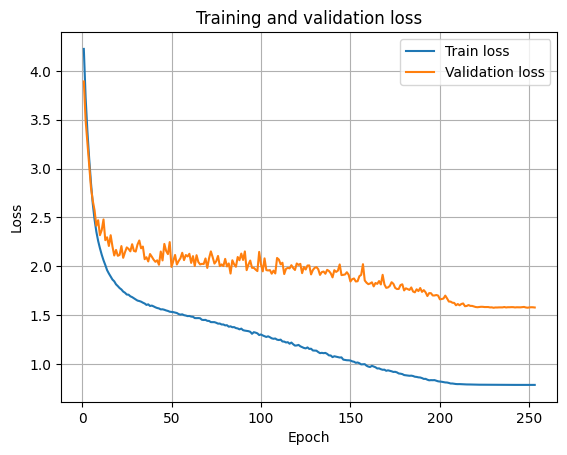

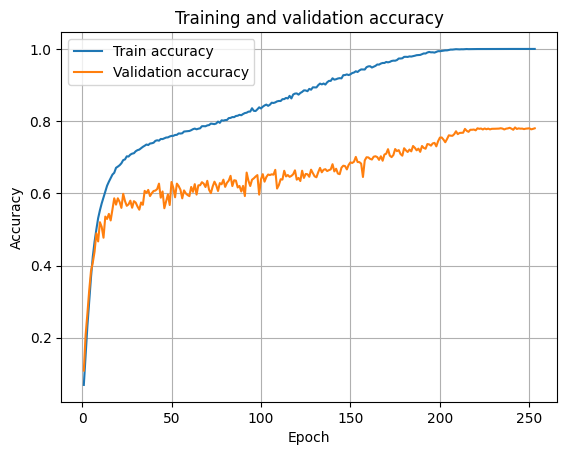

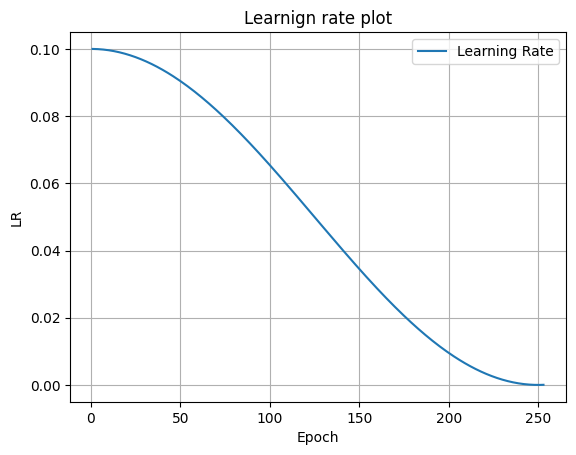

In [ ]:
draw_history(history_resnet34)

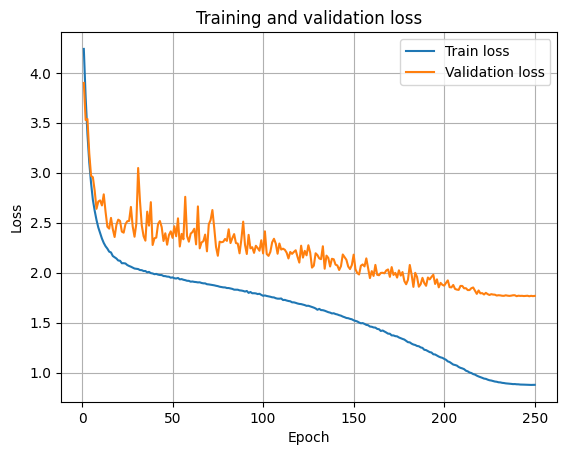

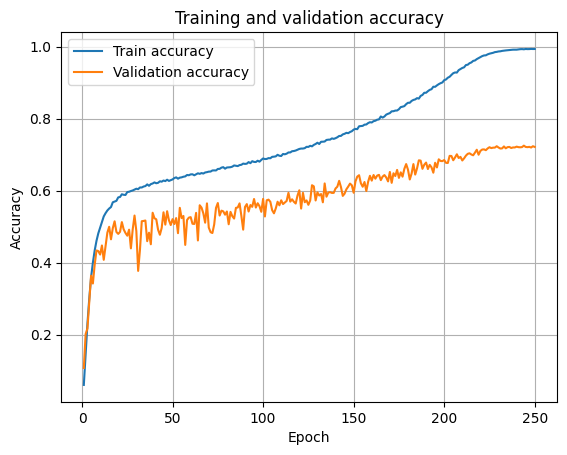

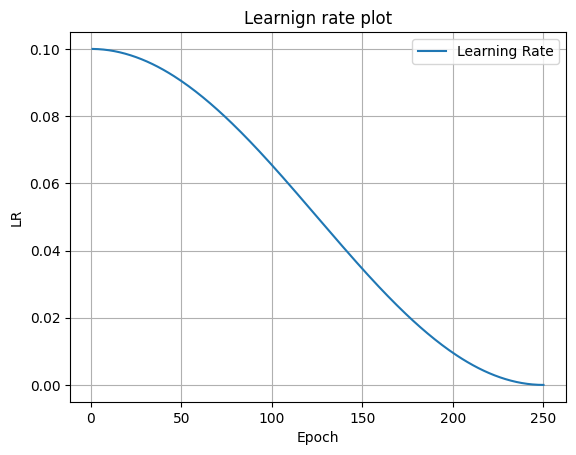

In [ ]:
draw_history(history_resnet56)